In [1]:
# replication with previous vacv k3 and delta-k3 experiment

In [5]:
import pickle
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import pearsonr, spearmanr
from matplotlib import ticker

In [4]:
# add pkr type
def pkr_type(x, pkr_stop = 551):
    if x[-1] == "*" and int(x.split('-')[1][1:-1]) < pkr_stop:
        return "Nonsense"
    elif x[-2:] == 'WT':
        return "WT"
    else:
        return 'Variant'

In [2]:
input_file = '../../data/prev-k3-data/combined_variant-reads_240305.csv'
df1 = pd.read_csv(input_file)
df1.k3.replace('K3L-Null', 'K3Δ58', inplace=True)
df1.k3.replace('K3L-WT', 'VACV K3', inplace=True)
df1['replicate'] = 'Replicate 240305'

input_file = '../../results/barseq/combined_variant-reads_241011.csv'
df2 = pd.read_csv(input_file)
df2['replicate'] = 'Replicate 241011'

In [6]:
# purify to designed pkr variants
input_file = '../../data/dms_primers/pkr_variants_list.pkl'
with open(input_file, 'rb') as f:
    designed_variant_list = pickle.load(f)
designed_variant_list = ["PKR-" + variant for variant in designed_variant_list]
designed_variant_list.append("PKR-WT")

In [3]:
k3 = 'VACV K3'
temp_df1 = df1.query('k3 == @k3')
temp_df2 = df2.query('k3 == @k3')
temp_df = pd.concat([temp_df1,temp_df2])
temp_df = temp_df.groupby(['replicate','k3','pkr'])['auc'].mean().reset_index()
temp_df = temp_df.pivot_table(index=['pkr','k3'], columns='replicate', values='auc').reset_index()
temp_df

replicate,pkr,k3,Replicate 240305,Replicate 241011
0,PKR-A488D,VACV K3,-1.008183,0.097070
1,PKR-A488G,VACV K3,6.137678,6.353255
2,PKR-A488P,VACV K3,-4.341356,-4.674444
3,PKR-A488S,VACV K3,1.580921,3.198287
4,PKR-A488T,VACV K3,-1.164396,1.126693
...,...,...,...,...
426,PKR-Y454D,VACV K3,-4.846921,-5.334014
427,PKR-Y454F,VACV K3,5.786251,5.465400
428,PKR-Y454H,VACV K3,2.582188,2.793520
429,PKR-Y454N,VACV K3,-3.085352,-3.237573


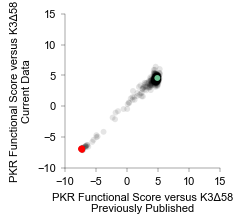

Pearson correlation coefficient: 0.9867455257690753
Spearman correlation coefficient: 0.5604952427201927


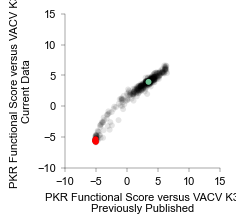

Pearson correlation coefficient: 0.97808279608431
Spearman correlation coefficient: 0.9672691954891275


In [8]:
replicate_conds = ['K3Δ58', 'VACV K3']

for k3 in replicate_conds:
    temp_df1 = df1.query('k3 == @k3')
    temp_df2 = df2.query('k3 == @k3')
    temp_df = pd.concat([temp_df1,temp_df2])
    temp_df = temp_df.groupby(['replicate','k3','pkr'])['auc'].mean().reset_index()
    temp_df = temp_df.pivot_table(index=['pkr','k3'], columns='replicate', values='auc').reset_index()
    temp_df = temp_df[~temp_df.isin([np.inf, -np.inf]).any(axis=1)]
    temp_df = temp_df.dropna()
    temp_df = temp_df[temp_df['pkr'].isin(designed_variant_list)]
    temp_df['pkr_type'] = temp_df['pkr'].apply(pkr_type)
    temp_df


    
    width_in = 2
    height_in = 2
    font_size = 8
    font_name = 'Arial'
    stroke = .25
    tick_len = 3
    alpha_val = .1
    marker_diameter = 3 # 1.75
    
    font = {'family': font_name, 'size': font_size}
    plt.rc('font', **font)
    plt.rc('lines', linewidth=stroke)
    plt.figure(figsize=(width_in, height_in)) # save size
    
    ax = sns.scatterplot(
        data=temp_df,
        x='Replicate 240305',
        y='Replicate 241011',
        color='black',
        alpha=alpha_val,
        size=3,
        legend=False,
        edgecolor='none',
    )

    # plot wt 
    ax = sns.scatterplot(
        data=temp_df.query('pkr_type == "WT"'),
        x='Replicate 240305',
        y='Replicate 241011',
        color='#6dc091',
        size=marker_diameter,
        legend=False,
        edgecolor='none',
        alpha=1
    )
    
    # plot nonsense mutations
    nonsense_vars = ["PKR-S275*","PKR-Q376*","PKR-R453*","PKR-E480*"]
    ax = sns.scatterplot(
        data=temp_df.query('pkr.isin(@nonsense_vars)'),
        x='Replicate 240305',
        y='Replicate 241011',
        color='red',
        size=marker_diameter,
        legend=False,
        edgecolor='none',
        alpha=1
    )
    
    # Remove top and right spines
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_linewidth(stroke)
    ax.spines['bottom'].set_linewidth(stroke)
    
    # Set x and y limits
    ax.set_xlim(-10, 15)
    ax.set_ylim(-10, 15)
    
    # Set tick parameters
    ax.tick_params(axis='both', which='both', direction='out', length=3, width=stroke)
    
    # Set font properties for axis labels
    ax.set_xlabel(f'PKR Functional Score versus {k3}\nPreviously Published', fontsize=font_size, fontname=font_name)
    ax.set_ylabel(f'PKR Functional Score versus {k3}\nCurrent Data', fontsize=font_size, fontname=font_name)
    
    # Set tick marks and labels every 5 units
    ax.xaxis.set_major_locator(ticker.MultipleLocator(5))
    ax.yaxis.set_major_locator(ticker.MultipleLocator(5))
    
    #plt.tight_layout()
    fig = ax.get_figure()
    fig.savefig(f'../../img/replication/prev-data_{k3}-replication_wt-nonsense.svg', format='svg', bbox_inches='tight', transparent=False)
    plt.show()
    
    # Calculate Pearson correlation
    pearson_corr, _ = pearsonr(temp_df['Replicate 240305'], temp_df['Replicate 241011'])
    print("Pearson correlation coefficient:", pearson_corr)
    
    # Calculate Spearman correlation
    spearman_corr, _ = spearmanr(temp_df['Replicate 240305'], temp_df['Replicate 241011'])
    print("Spearman correlation coefficient:", spearman_corr)

In [10]:
df2.k3.unique()

array(['K3Δ58', 'RCVZ vIF2α', 'VACV K3', 'VARV C3', 'MYXV M156R',
       'TPV K3'], dtype=object)